In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:

X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=7
)


In [3]:
print("X shape:", X.shape)
print("First 5 rows:\n", X[:5])

X shape: (500, 2)
First 5 rows:
 [[  0.13445257   4.27340548]
 [ -2.73147166   2.67219757]
 [ -8.6030347    3.91666624]
 [  0.78360792   3.74629082]
 [ -0.84815475 -10.43337235]]


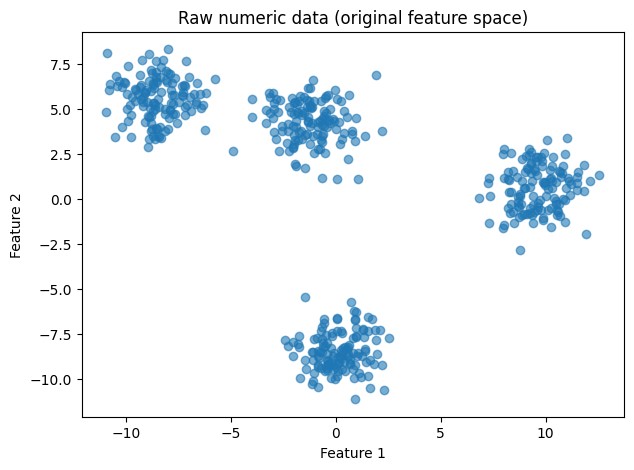

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], alpha=0.6)
plt.title("Raw numeric data (original feature space)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Why scaling matters:
	•	k-Means uses distance
	•	PCA uses variance and covarianceDistance and variance depend on feature units.

If one feature has much larger numeric values:
	•	it dominates Euclidean distance
	•	it dominates varianceSo we standardize.
  
StandardScaler performs:z_ij = (x_ij − mean_j) / std_j

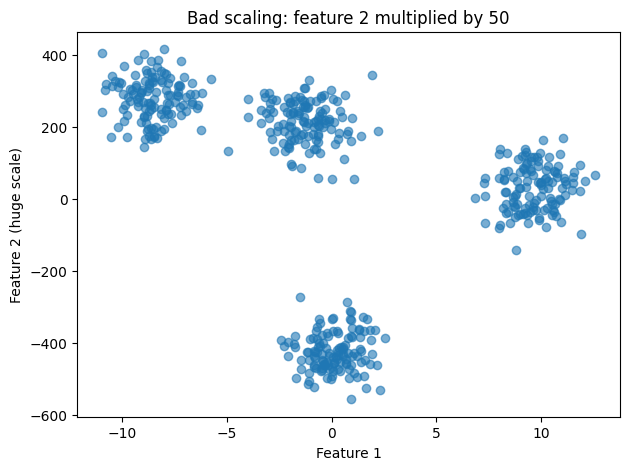

In [5]:

X_bad = X.copy()
X_bad[:,1] *= 50  # exaggerate scale of feature 2

plt.figure(figsize=(7,5))
plt.scatter(X_bad[:,0], X_bad[:,1], alpha=0.6)
plt.title("Bad scaling: feature 2 multiplied by 50")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2 (huge scale)")
plt.show()

Means after scaling: [1.15463195e-16 1.85407245e-17]
Std after scaling: [1. 1.]


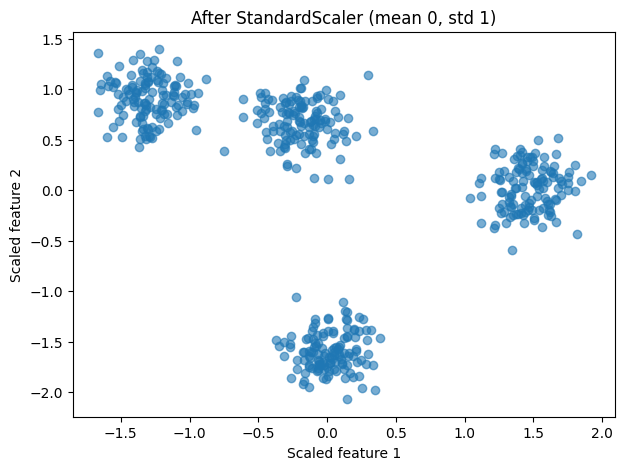

In [6]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_bad)

print("Means after scaling:", X_std.mean(axis=0))
print("Std after scaling:", X_std.std(axis=0))

plt.figure(figsize=(7,5))
plt.scatter(X_std[:,0], X_std[:,1], alpha=0.6)
plt.title("After StandardScaler (mean 0, std 1)")
plt.xlabel("Scaled feature 1")
plt.ylabel("Scaled feature 2")
plt.show()


PCA goal (plain language):Find new axes that capture the most variance.
PC1:
	•	the direction where the projected data varies the most


PC2:
	•	the next direction with maximum variance
	•	must be orthogonal (perpendicular) to PC1


Math objects:
	1	Center data (subtract mean)
	2	Compute covariance matrixSigma = (1/(n-1)) * (X_centered^T * X_centered)
	3	Eigenvectors and eigenvaluesSigma * w = lambda * w


Meaning:
	•	w = direction (principal component)
	•	lambda = variance captured in that direction


  Explained variance ratio:EVR_j = lambda_j / sum(all lambdas)

Explained variance ratio: [0.66274119 0.33725881]
Total explained variance: 1.0


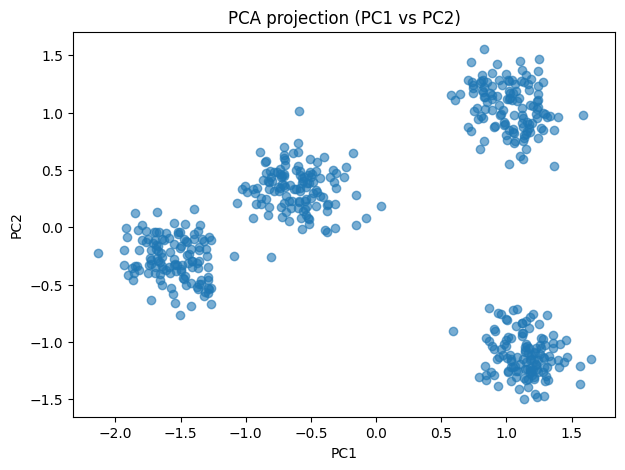

In [7]:

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.title("PCA projection (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

K Means:

Goal:Choose k centroids that minimize within-cluster squared distance.
Objective:J = sum_i || x_i − mu_{c(i)} ||^2

Algorithm (repeat):
	1	Assign each point to nearest centroid

	2	Update each centroid to the mean of its assigned points
  
Centroid meaning:The centroid is the average location of points in the cluster.

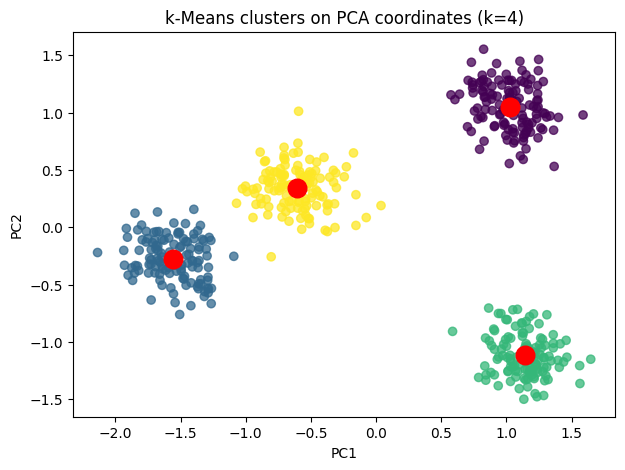

In [8]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X_pca)
centers = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, alpha=0.75)
plt.scatter(centers[:,0], centers[:,1], c="red", s=180)
plt.title("k-Means clusters on PCA coordinates (k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Means after scaling: [1.15463195e-16 1.85407245e-17]
Std after scaling: [1. 1.]


Text(0, 0.5, 'Scaled feature 2')

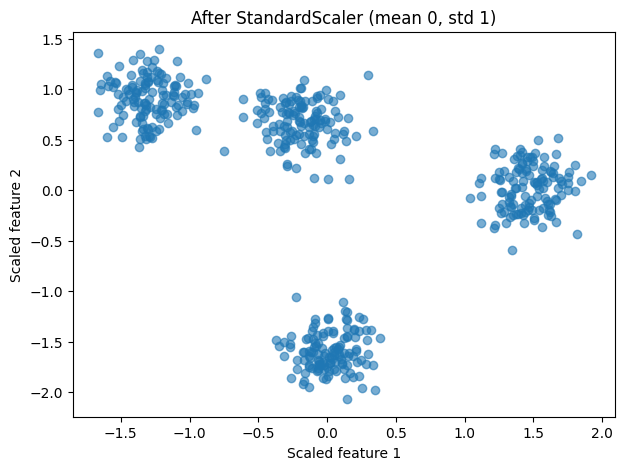

In [9]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_bad)

print("Means after scaling:", X_std.mean(axis=0))
print("Std after scaling:", X_std.std(axis=0))

plt.figure(figsize=(7,5))
plt.scatter(X_std[:,0], X_std[:,1], alpha=0.6)
plt.title("After StandardScaler (mean 0, std 1)")
plt.xlabel("Scaled feature 1")
plt.ylabel("Scaled feature 2")

Problem: Text is not numeric.

Solution:Convert documents into vectors.

Vector space model:
	•	each term = a dimension
	•	each document = a vector in that space
We will use TF-IDF.

TF = term frequency (importance inside one document)TF(t,d) = count of term t in document d

DF = document frequency (how common across all docs)DF(t) = number of documents containing term t

IDF = inverse document frequency (rarity weight)IDF(t) = log(N / DF(t))

TF-IDF weight:TFIDF(t,d) = TF(t,d) * IDF(t)

In [10]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

docs = [
    "COVID-19 vaccine trial shows strong immune response and antibodies.",
    "SARS-CoV-2 transmission increases in indoor settings with poor ventilation.",
    "ICU admission risk is higher for patients with diabetes and hypertension.",
    "Masking and public health interventions reduce viral spread in communities.",
    "Antiviral treatment reduces viral load and improves recovery time in hospitalized patients.",
    "Genomic sequencing reveals variants with spike protein mutations and immune escape.",
    "Long COVID symptoms include fatigue, brain fog, and shortness of breath.",
    "mRNA vaccines produce neutralizing antibodies and reduce severe disease."
]

for i, d in enumerate(docs):
    print(i, ":", d)

vectorizer = TfidfVectorizer(stop_words="english")
X_tfidf = vectorizer.fit_transform(docs)

terms = vectorizer.get_feature_names_out()
print("\nTF-IDF shape (docs x terms):", X_tfidf.shape)
print("First 25 terms:", terms[:25])


0 : COVID-19 vaccine trial shows strong immune response and antibodies.
1 : SARS-CoV-2 transmission increases in indoor settings with poor ventilation.
2 : ICU admission risk is higher for patients with diabetes and hypertension.
3 : Masking and public health interventions reduce viral spread in communities.
4 : Antiviral treatment reduces viral load and improves recovery time in hospitalized patients.
5 : Genomic sequencing reveals variants with spike protein mutations and immune escape.
6 : Long COVID symptoms include fatigue, brain fog, and shortness of breath.
7 : mRNA vaccines produce neutralizing antibodies and reduce severe disease.

TF-IDF shape (docs x terms): (8, 62)
First 25 terms: ['19' 'admission' 'antibodies' 'antiviral' 'brain' 'breath' 'communities'
 'cov' 'covid' 'diabetes' 'disease' 'escape' 'fatigue' 'fog' 'genomic'
 'health' 'higher' 'hospitalized' 'hypertension' 'icu' 'immune' 'improves'
 'include' 'increases' 'indoor']


cos(x,y) = (x dot y) / (||x|| * ||y||)

Why cosine for text:
	•	normalizes for document length

	•	compares word usage patterns
Interpretation:
	•	near 1 = similar
  
	•	near 0 = different

In [11]:

from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X_tfidf)
print("Cosine similarity (rounded):\n", np.round(sim, 2))

Cosine similarity (rounded):
 [[1.   0.   0.   0.   0.   0.08 0.08 0.09]
 [0.   1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.09 0.   0.   0.  ]
 [0.   0.   0.   1.   0.08 0.   0.   0.09]
 [0.   0.   0.09 0.08 1.   0.   0.   0.  ]
 [0.08 0.   0.   0.   0.   1.   0.   0.  ]
 [0.08 0.   0.   0.   0.   0.   1.   0.  ]
 [0.09 0.   0.   0.09 0.   0.   0.   1.  ]]


TF-IDF is sparse and high-dimensional.TruncatedSVD reduces sparse matrices directly.It plays a PCA-like role for text.
Goal:
	•	get a 2D view so humans can see structure

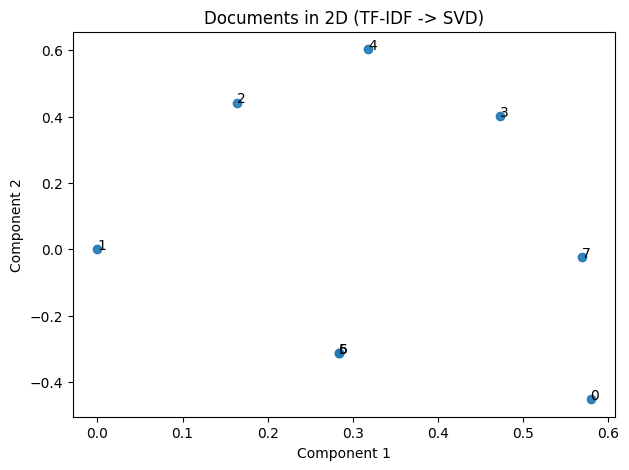

In [12]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=0)
X_2d = svd.fit_transform(X_tfidf)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.9)

for i in range(len(docs)):
    plt.text(X_2d[i,0], X_2d[i,1], str(i))

plt.title("Documents in 2D (TF-IDF -> SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

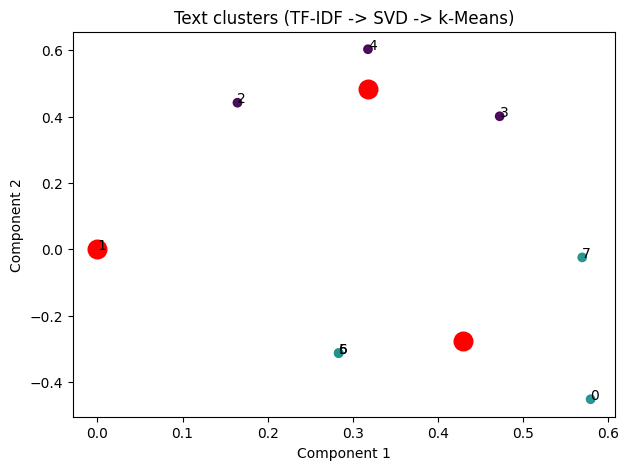

In [13]:
from sklearn.cluster import KMeans

k = 3
kmeans_text = KMeans(n_clusters=k, random_state=0)
labels_2d = kmeans_text.fit_predict(X_2d)
centers_2d = kmeans_text.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_2d, alpha=0.95)
plt.scatter(centers_2d[:,0], centers_2d[:,1], c="red", s=180)

for i in range(len(docs)):
    plt.text(X_2d[i,0], X_2d[i,1], str(i))

plt.title("Text clusters (TF-IDF -> SVD -> k-Means)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [14]:
kmeans_tfidf = KMeans(n_clusters=3, random_state=0)
labels_tfidf = kmeans_tfidf.fit_predict(X_tfidf)

centers = kmeans_tfidf.cluster_centers_
terms = np.array(vectorizer.get_feature_names_out())

for c in range(3):
    top_idx = centers[c].argsort()[-10:][::-1]
    print("\nCLUSTER", c, "TOP TERMS:", ", ".join(terms[top_idx]))
    print("DOCUMENTS:")
    for i, doc in enumerate(docs):
        if labels_tfidf[i] == c:
            print("-", i, ":", doc)


CLUSTER 0 TOP TERMS: patients, risk, diabetes, hypertension, icu, higher, admission, load, hospitalized, improves
DOCUMENTS:
- 2 : ICU admission risk is higher for patients with diabetes and hypertension.
- 4 : Antiviral treatment reduces viral load and improves recovery time in hospitalized patients.

CLUSTER 1 TOP TERMS: covid, vaccine, strong, shows, response, trial, 19, breath, shortness, fatigue
DOCUMENTS:
- 0 : COVID-19 vaccine trial shows strong immune response and antibodies.
- 6 : Long COVID symptoms include fatigue, brain fog, and shortness of breath.

CLUSTER 2 TOP TERMS: reduce, vaccines, produce, public, severe, spread, interventions, health, communities, disease
DOCUMENTS:
- 1 : SARS-CoV-2 transmission increases in indoor settings with poor ventilation.
- 3 : Masking and public health interventions reduce viral spread in communities.
- 5 : Genomic sequencing reveals variants with spike protein mutations and immune escape.
- 7 : mRNA vaccines produce neutralizing antibodi

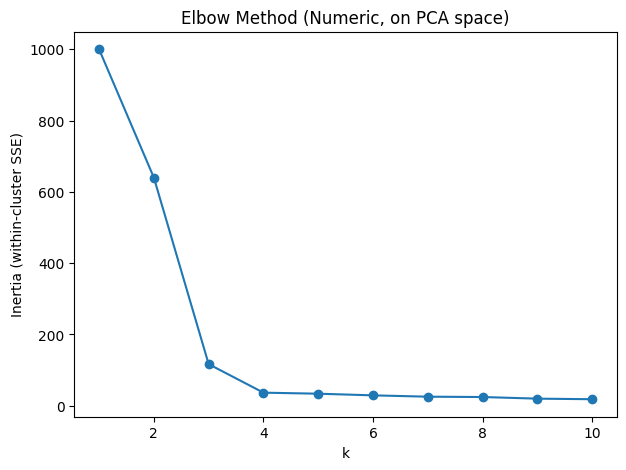

In [15]:
inertias = []
K = range(1, 11)

for kk in K:
    km = KMeans(n_clusters=kk, random_state=0)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K), inertias, marker="o")
plt.title("Elbow Method (Numeric, on PCA space)")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.show()


For each point i:a(i) = average distance to points in its clusterb(i) = smallest average distance to points in another cluster
Silhouette:s(i) = (b(i) − a(i)) / max(a(i), b(i))
Interpretation:
	•	near +1: well separated
	•	near 0: overlapping
	•	negative: likely misclustered

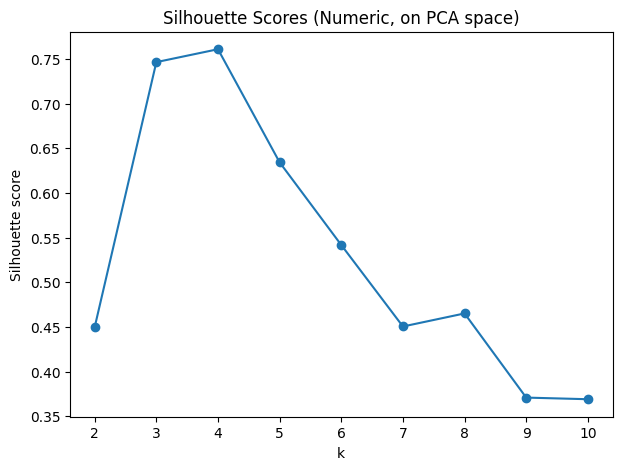

In [16]:
from sklearn.metrics import silhouette_score

scores = []
K = range(2, 11)  # silhouette needs at least 2 clusters

for kk in K:
    km = KMeans(n_clusters=kk, random_state=0)
    labels_k = km.fit_predict(X_pca)
    s = silhouette_score(X_pca, labels_k)
    scores.append(s)

plt.figure(figsize=(7,5))
plt.plot(list(K), scores, marker="o")
plt.title("Silhouette Scores (Numeric, on PCA space)")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()


In [17]:
best_k = list(K)[int(np.argmax(scores))]
print("Best k by silhouette:", best_k)

Best k by silhouette: 4


What does “unsupervised discovery” mean?

Filled answers:
	1	PCA/SVD helped me see: dominant directions of variation and a 2D view of structure

	2	k-Means grouped: points/documents by similarity under the chosen representation

	3	A cluster represents: a pattern-based grouping, not a truth label

	4	Interpretation required because: the algorithm outputs structure, not meaning

	5	One limitation/risk: clusters depend on scaling, metric, k choice, and can be misinterpreted or stigmatizing

Ethics reminder:
	•	do not label clusters in a harmful way

	•	report themes, not individuals
  
	•	de-identified text can still contain sensitive patterns

Why k-Means assumes spherical cluster
 Why PCA can hide clusters

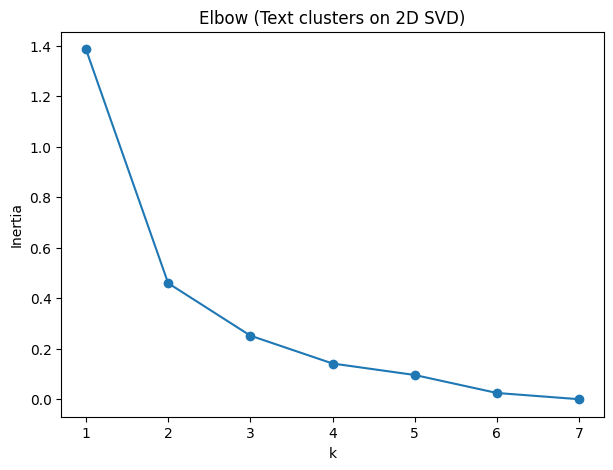

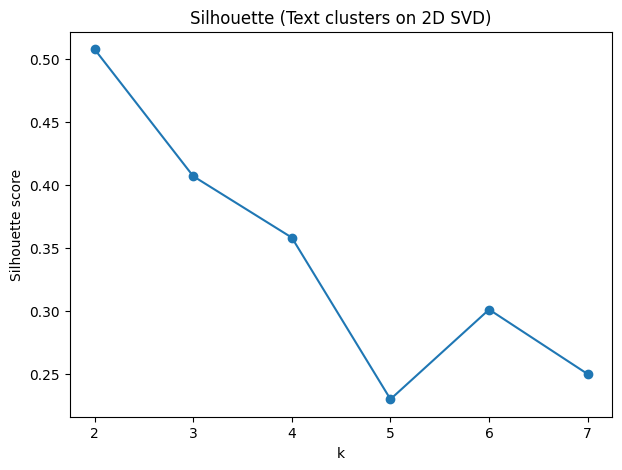

In [18]:

from sklearn.metrics import silhouette_score

# elbow on 2D text space
inertias = []
K = range(1, 8)
for kk in K:
    km = KMeans(n_clusters=kk, random_state=0)
    km.fit(X_2d)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K), inertias, marker="o")
plt.title("Elbow (Text clusters on 2D SVD)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# silhouette on 2D text space
scores = []
K2 = range(2, 8)
for kk in K2:
    km = KMeans(n_clusters=kk, random_state=0)
    labels_k = km.fit_predict(X_2d)
    scores.append(silhouette_score(X_2d, labels_k))

plt.figure(figsize=(7,5))
plt.plot(list(K2), scores, marker="o")
plt.title("Silhouette (Text clusters on 2D SVD)")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()
